The following code is adapted from this website here: https://medium.com/nerd-for-tech/building-an-image-classifier-with-tensorflow-3e12c1d5d3a2

July 10, 2024

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import pathlib


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [22]:
#import folders for train and test
image_directory = "..\\images_combined"

batch_size = 25
img_size = 227

In [63]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    image_directory,
    validation_split = 0.2,
    subset = "training",
    seed = 696,
    image_size = (img_size,img_size),
    batch_size = batch_size
)
validation_ds = tf.keras.preprocessing.image_dataset_from_directory(
    image_directory,
    validation_split = 0.2,
    subset = "validation",
    seed = 696,
    image_size = (img_size,img_size),
    batch_size = batch_size
)
print(train_ds.class_names)

Found 16695 files belonging to 4 classes.
Using 13356 files for training.
Found 16695 files belonging to 4 classes.
Using 3339 files for validation.
['good', 'spaghetti', 'stringing', 'underextrusion']


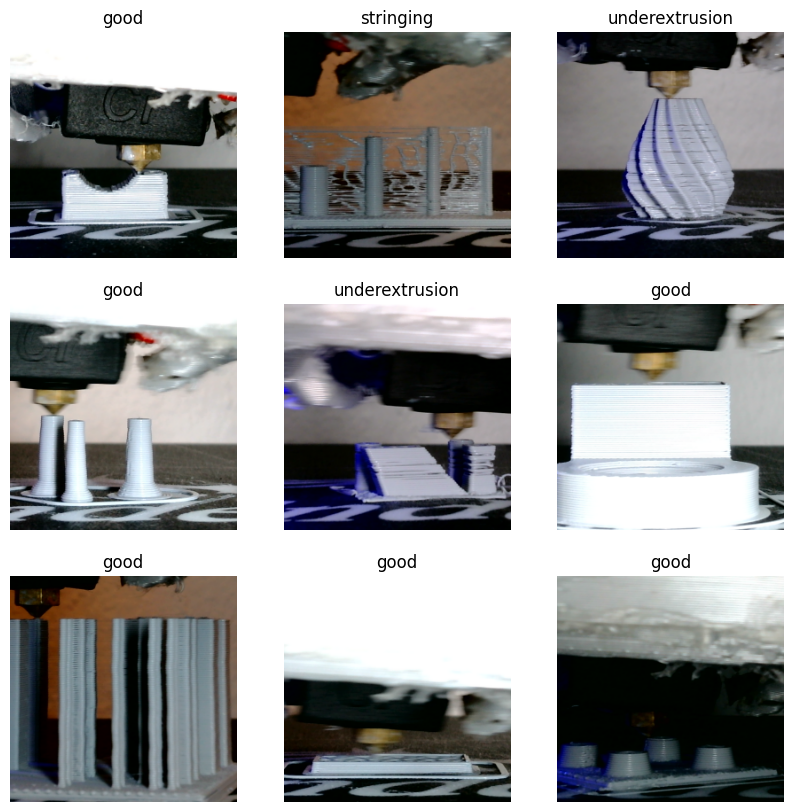

In [64]:
class_names = train_ds.class_names
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [70]:

num_classes = 4
model_from_website = Sequential([
  layers.Rescaling(1./255, input_shape=(img_size, img_size, 3)),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])
# AlexNet_model = Sequential([
#     layers.Rescaling(1./255, input_shape=(img_size, img_size, 3)), 
#     layers.Conv2D(96, 11, strides=4, padding='same'),
#     layers.Lambda(tf.nn.local_response_normalization),
#     layers.Activation('relu'),
#     layers.MaxPooling2D(3, strides=2),
#     layers.Conv2D(256, 5, strides=4, padding='same'),
#     layers.Lambda(tf.nn.local_response_normalization),
#     layers.Activation('relu'),
#     layers.MaxPooling2D(3, strides=2),
#     layers.Conv2D(384, 3, strides=4, padding='same'),
#     layers.Activation('relu'),
#     layers.Conv2D(384, 3, strides=4, padding='same'),
#     layers.Activation('relu'),
#     layers.Conv2D(256, 3, strides=4, padding='same'),
#     layers.Activation('relu'),
#     layers.Flatten(),
#     layers.Dense(4096, activation='relu'),
#     layers.Dropout(0.5),
#     layers.Dense(4096, activation='relu'),
#     layers.Dropout(0.5),
#     layers.Dense(num_classes, activation='softmax')
# ])

#ChatGPT version of alexnet
AlexNet_model = Sequential([
    layers.Rescaling(1./255, input_shape=(img_size, img_size, 3)), 
    layers.Conv2D(96, (11, 11), strides=(4, 4), padding='same', activation='relu'),
    layers.Lambda(tf.nn.local_response_normalization),
    layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2)),
    
    layers.Conv2D(256, (5, 5), padding='same', activation='relu'),
    layers.Lambda(tf.nn.local_response_normalization),
    layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2)),
    
    layers.Conv2D(384, (3, 3), padding='same', activation='relu'),
    layers.Conv2D(384, (3, 3), padding='same', activation='relu'),
    layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2)),

    layers.Flatten(),
    layers.Dense(4096, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4096, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

#model.summary()

In [71]:
AlexNet_model.compile(optimizer='Adam'
  , loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
  , metrics=['accuracy'])

model_from_website.compile(optimizer='Adam'
  , loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
  , metrics=['accuracy'])


In [72]:
epochs = 10
history = AlexNet_model.fit(train_ds,validation_data=validation_ds, epochs = epochs)


Epoch 1/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 389s 722ms/step - accuracy: 0.4206 - loss: 1.2760 - val_accuracy: 0.4271 - val_loss: 1.1390
Epoch 2/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 385s 720ms/step - accuracy: 0.4302 - loss: 1.1452 - val_accuracy: 0.4271 - val_loss: 1.1345
Epoch 3/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 384s 717ms/step - accuracy: 0.4321 - loss: 1.1449 - val_accuracy: 0.4271 - val_loss: 1.1346
Epoch 4/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 384s 717ms/step - accuracy: 0.4307 - loss: 1.1434 - val_accuracy: 0.4271 - val_loss: 1.1342
Epoch 5/10
127/535 ━━━━━━━━━━━━━━━━━━━━ 4:37 681ms/step - accuracy: 0.4265 - loss: 1.1385

KeyboardInterrupt: 

In [62]:
image_path = "..\\test_image\\spaghetti.jpg"
img = keras.preprocessing.image.load_img(image_path, target_size=(img_size, img_size))
img_arr = keras.preprocessing.image.img_to_array(img)
img_arr = tf.expand_dims(img_arr, 0)


predictions = model_from_website.predict(img_arr)
class_names = ['good', 'spaghetti', 'stringing', 'underextrusion']
predicted_index = np.argmax(predictions)
predicted_label = class_names[predicted_index]

print(f"The predicted image is an example of: {predicted_label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
The predicted image is an example of: spaghetti
